# 神经网络启蒙：PyTorch实战入门

## 介绍

接着上一章，本章我们将正式迈入神经网络的大门。在上一章中，我们通过“训练机器人制作柠檬水”的故事，亲手实现了一个仅含单个参数的线性回归模型，完整走过了从模型定义、前向计算、损失评估到手动反向传播与参数更新的全过程，并深入理解了学习率对训练动态的影响。这一过程虽然简单，却为我们打下了机器学习最核心的基础。

本章则在此基础上迈出关键一步：我们将任务从单参数扩展到多参数，从手动推更新导梯度转向利用神经网络的反向传播自动计算；不再手动管理参数更新逻辑，而是借助优化器自动完成这一过程；更重要的是，我们将告别纯手动训练模型的方式，开始使用 PyTorch 这一现代深度学习框架来构建和训练模型。亲身体验PyTorch 是如何将我们从繁琐的底层计算中解放出来的，从而让我们更专注于模型结构设计与训练流程的构建。

本章的目标很明确：从零构建并训练你的第一个神经网络模型。为了这一核心目标，本章会优先保证代码的可读性与概念的直观性，因此模型结构会保持简单，数据集也相对较小。虽仍是一个“玩具模型”，但也足以让你清晰看到神经网络“如何工作”以及 PyTorch “如何帮你工作”。

现在，就让我们一起训练属于你的第一个神经网络模型，开启这段激动人心的学习之旅吧！

## 任务背景

你是一个程序员，名字叫小吾。自从上次和小美合作，成功教会机器人掌握制作柠檬水的技巧，你的无人柠檬水摊位小火了一把。看着账户里稳定增长的数字，一个更“大胆”的想法又冒了出来：如果只卖经典原味，天花板触手可及。如果能让机器人学会如何开发出各种口味的特调柠檬水，那将大大提升你的收入。

你可以在基础柠檬水中加入薄荷叶、百香果、黄瓜片或少许海盐来创造不同的风味。薄荷带来清凉感，黄瓜增加清新的后韵，而一点点玫瑰盐则能神奇地提升整体的层次感，但它们彼此之间会相互影响，如何平衡它们才是真正的艺术。

你使用不同的配比来尝试各种组合，然后让顾客进行评价，并记录下来，慢慢优化，但是开发过程漫长且成本高昂。所以你就想如果能训练一个模型自动对不同的配比预测顾客的评分，那么问题就迎刃而解了。

## 最少必要知识

- 神经网络概论
- Pytorch 基础

## 环境版本

打印环境的版本号，避免因为环境不同而导致程序不能复现。

In [1]:
from course_02.util import show_version

show_version()

+------+----------------------------------------------------------------------------------------+
| Info |                                   《动手学人工智能》                                   |
+------+----------------------------------------------------------------------------------------+
| 作者 |                                       吾辈亦有感                                       |
| 哔站 |                      https://space.bilibili.com/3461565265217538                       |
| 定位 |      基于'从零构建'的理念，用实战降低学习大模型的门槛，帮助程序员快速入门大模型。      |
| 愿景 | 若我的经验能让你的AI学习之路走的更容易一点，让你的生活变得更美好，我将倍感荣幸！祝好😄 |
+------+----------------------------------------------------------------------------------------+

环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.9.1     |         2.6.0          |
+-------------+--------------+------------------------+


## 准备数据


### 观察数据

预览数据集前5行数据，直观掌握数据的结构，根据需要对数据进行预处理。


In [2]:
# 读取数据
import pandas as pd

# 读取训练集数据
train_df = pd.read_csv('./dataset/craft_lemonade_train.csv')
train_df[:5]

,薄荷叶,黄瓜片,玫瑰盐,顾客评分
0,9,10,6,8.60
1,10,9,7,8.90
2,5,3,7,4.80
3,3,4,6,4.10
4,4,9,2,5.25


从输出结果可以看到数据包含四个字段：薄荷叶、黄瓜片、玫瑰盐（输入特征）和 顾客评分（目标值），这是一个典型的多参数回归问题的数据集。

### 定义数据加载方法

根据文件路径加载 `csv` 数据，分离出输入特征与对应的目标值并分别返回。

In [3]:
def load_data(file_path):
    # 读取 csv 数据
    data_frame = pd.read_csv(file_path)

    # 将DataFrame数据转换为列表格式
    features = data_frame[['薄荷叶', '黄瓜片', '玫瑰盐']].values.tolist()
    target_scores = data_frame[['顾客评分']].values.tolist()

    return features, target_scores

### 加载训练集和评估集

加载训练数据和评估数据，并打印训练集和评估集的样本数量，确认数据加载成功。

In [4]:
train_features, train_targets = load_data('./dataset/craft_lemonade_train.csv')
val_features, val_targets = load_data('./dataset/craft_lemonade_val.csv')

print(f"训练数据集样本数量：{len(train_features)}")
print(f"评估数据集样本数量：{len(val_features)}")

训练数据集样本数量：800
评估数据集样本数量：200


## 模型定义

创建一个用于柠檬水评分预测的模型，学习三种配料与顾客评分之间的关系。其模型结构如下：

![image.png](https://qingsong-1257401904.cos.ap-nanjing.myqcloud.com/20251226151815.png)

本次任务我们使用 PyTorch 构建一个神经网络模型，创建一个继承自 `nn.Module` 的 `LemonadeRatingModel` 类，这是PyTorch中定义神经网络模型的标准方式。

重写模型的 `__init__` 和 `forward` 方法，分别完成模型的初始化和前向计算。
- `__init__` 方法：定义模型的参数和层结构，创建一个拥有3个输入特征，1个输出特征的线性层。
- `forward` 方法：定义数据在网络中的流动方式，通过前向计算根据输入特征预测顾客评分。


In [5]:
import torch
import torch.nn as nn


# 定义柠檬水评分预测模型,继承自 nn.Module，这是PyTorch中定义神经网络的标准方式
class LemonadeRatingModel(nn.Module):
    def __init__(self):
        super(LemonadeRatingModel, self).__init__()
        # 创建一个线性层：接受3个输入特征（薄荷叶、黄瓜片、玫瑰盐）并输出1个值（顾客评分）
        self.rating_predictor_layer = nn.Linear(in_features=3, out_features=1, bias=False)

    def forward(self, input_features):
        # 前向计算，定义数据在网络中的流动方式，预测顾客评分，forward 方法会被自动调用
        predicted_rating = self.rating_predictor_layer(input_features)
        return predicted_rating

创建一个模型实例，并打印模型结构，确认模型创建成功。

In [6]:
from course_01.util import print_red

# 创建模型实例
model = LemonadeRatingModel()

print_red("模型结构：")
print(model)

模型结构：
LemonadeRatingModel(
  (rating_predictor_layer): Linear(in_features=3, out_features=1, bias=False)
)


从运行结果可以看到柠檬水评分模型的结构，模型中只有一个分数预测的线性层，其输入特征为3个（薄荷叶、黄瓜片、玫瑰盐），输出特征为1个（顾客评分）。

## 模型训练

### 定义训练方法

定义一个训练神经网络模型函数 `train_model`，指定的训练轮数，在每个轮中实现一次完整的神经网络训练循环，并且定期记录训练过程中损失变化的日志信息。

**训练循环的关键步骤：**
- **前向传播**：让模型根据输入特征（薄荷叶、黄瓜片、玫瑰盐用量）预测顾客评分
- **损失计算**：比较预测结果与真实评分的差距，量化模型的"错误程度"
- **清空梯度**：清空优化器之前的梯度，避免梯度累积，影响模型训练效果
- **反向传播**：自动计算每个参数对错误的贡献度（梯度），确认模型参数更新方向和尺度
- **参数更新**：使用优化器调整模型参数，让下次预测更准确



In [7]:
def train_model(model, train_features, train_targets, loss_fn, optimizer, num_epochs=100, log_interval=5):
    """
    训练模型并记录训练日志
    
    参数:
    model: 要训练的模型
    train_features: 训练特征数据张量
    train_targets: 训练标签数据张量
    loss_fn: 损失函数
    optimizer: 优化器
    num_epochs: 训练轮数，默认为100
    log_interval: 日志记录间隔，默认为5
    
    返回:
    training_logs: 包含训练过程记录的列表
    """

    training_logs = []

    for epoch in range(num_epochs):
        # 1. 前向传播：使用模型预测评分
        predictions = model(train_features)

        # 2. 计算损失：使用损失函数计算预测评分与真实分数的差距
        loss = loss_fn(predictions, train_targets)

        # 3. 清空梯度：将模型参数的梯度清空，避免梯度累积
        optimizer.zero_grad() 
        
        # 4. 反向传播，计算梯度
        loss.backward()

        # 5. 使用优化器，更新参数
        optimizer.step() 


        # 记录训练日志
        if (epoch + 1) % log_interval == 0:
            # 记录模型参数
            with torch.no_grad():
                for param_name, param in model.named_parameters():
                    if param.requires_grad:  # 筛选需要计算计算梯度进行更新的参数
                        weights_list = param.data.numpy()[0].tolist()

                        # 获取模型权重
                        mint_leaf_weight, cucumber_slice_weight, rose_salt_weight = weights_list[0], weights_list[1], weights_list[2]

                        # 记录训练日志
                        training_logs.append({
                            "Epoch": epoch + 1,
                            "Loss": loss.item(),
                            "薄荷叶权重": mint_leaf_weight,
                            "黄瓜片权重": cucumber_slice_weight,
                            "玫瑰盐权重": rose_salt_weight
                        })

    return training_logs

### 训练模型

定义好了训练方法后，可以开始训练模型了。训练模型需要以下步骤：
- 超参数配置：定义训练轮数、日志记录间隔、学习率等超参数
- 准备训练数据：将训练的输入数据和标签数据转换为张量
- 初始化模型训练组件：创建模型实例、损失函数和优化器
    - 损失函数：因为此任务为回归任务，使用均方误差损失函数（MSE）
    - 优化器：使用随机梯度下降优化器（SGD）优化模型参数，学习率为0.001
- 执行训练循环：调用 `train_model` 函数进行500轮训练，每20轮记录一次训练日志。

In [8]:
from course_02.util import show_table

# 1. 超参数配置
num_epochs=500
log_interval=20
learning_rate = 0.001

# 2. 准备训练数据：将原始特征和目标值数组转换为 PyTorch 张量格式，指定数据类型为float32
train_features_tensor = torch.tensor(train_features, dtype=torch.float32)
train_targets_tensor = torch.tensor(train_targets, dtype=torch.float32)

# 3. 初始化模型训练组件：创建模型实例、损失函数和优化器
model = LemonadeRatingModel()  # 创建模型实例
loss_fn = nn.MSELoss()  # 使用均方误差损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  # 使用随机梯度下降优化器

# 4. 执行训练循环：调用训练方法进行500轮训练
training_logs = train_model(model, train_features_tensor, train_targets_tensor, loss_fn, optimizer, num_epochs=num_epochs, log_interval=log_interval)

# 5. 过程监控：以表格形式展示训练过程中的关键指标变化
print_red("模型训练日志：")
show_table(training_logs)

模型训练日志：


,Epoch,Loss,薄荷叶权重,黄瓜片权重,玫瑰盐权重
0,20,3.2451,-0.0752,0.4134,0.6490
1,40,1.6913,0.0591,0.3963,0.5410
2,60,0.8825,0.1542,0.3825,0.4608
3,80,0.4605,0.2227,0.3727,0.4027
4,100,0.2403,0.2721,0.3659,0.3606
5,120,0.1254,0.3078,0.3611,0.3301
6,140,0.0654,0.3335,0.3578,0.3080
7,160,0.0342,0.3520,0.3554,0.2920
8,180,0.0178,0.3654,0.3538,0.2805
9,200,0.0093,0.3750,0.3527,0.2721


从训练日志中可以看出随着训练的进行，损失值不断下降，逐步降至接近0，表示模型预测准确性不断提高。

### 训练过程可视化

绘制训练过程中损失值和重要权重的变化曲线，更直观地观察损失值和各参数权重在训练过程中的变化趋势。

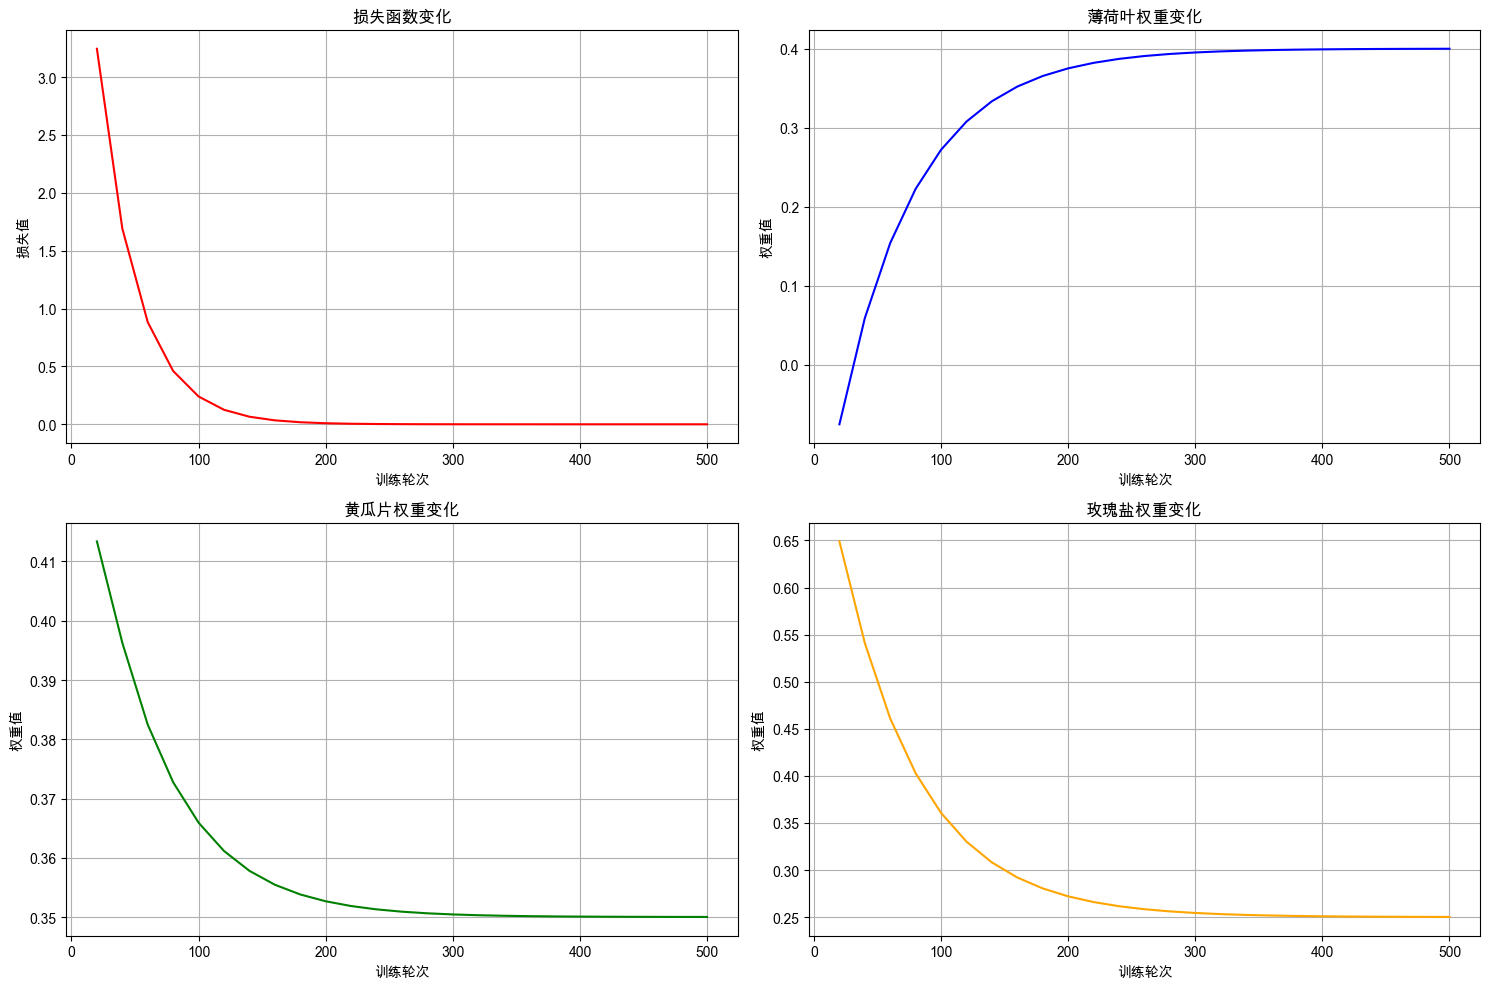

In [9]:
from util import plot_training_logs

# 绘制训练日志图像
plot_training_logs(training_logs)

从训练的过程中我们可以看到，所有参数在约200轮后基本收敛，三个配料权重都趋于稳定，说明模型确实找到了它们的配比与顾客评分之间的关系。而且总体来看，变化的趋势很平滑，说明模型训练过程非常稳定。

## 模型评估

模型训练完成后，需要评估模型在未见过的新数据上的表现，即评估模型的泛化能力。
1. 评估时，使用 `torch.no_grad()` 关闭梯度计算，可以在推理过程中不存储中间结果，减少显存占用
2. 将评估数据转换为 Pytorch 张量
3. 使用训练好的模型对新的柠檬水进行评分
4. 计算预测评分和真实评分的偏差和准确率

In [10]:
# 模型评估

with torch.no_grad():  # 关闭梯度计算

    # 转换为张量
    val_features_tensor = torch.tensor(val_features, dtype=torch.float32)  

    # 使用训练好的模型对柠檬水进行评分
    predicted = model(val_features_tensor).numpy()  

    # 使用 show_table 显示评估结果
    data = []
    for i in range(len(val_features)):
        residual = predicted[i][0] - val_targets[i][0]  # 预测的偏差
        accuracy_ratio = 1 - abs(residual) / val_targets[i][0]  # 预测的准确率比例

        data.append({
            "薄荷叶": val_features[i][0],
            "黄瓜片": val_features[i][1],
            "玫瑰盐": val_features[i][2],
            "真实评分": val_targets[i][0],
            "模型预测": predicted[i][0],
            "模型偏差": f"{residual:.4f}",
            "模型精度": f"{accuracy_ratio * 100:.2f}%"
        })

    show_table(data)

,薄荷叶,黄瓜片,玫瑰盐,真实评分,模型预测,模型偏差,模型精度
0,1,8,2,3.7000,3.7002,0.0002,99.99%
1,1,2,3,1.8500,1.8504,0.0004,99.98%
2,9,8,3,7.1500,7.1489,-0.0011,99.98%
3,1,10,9,6.1500,6.1515,0.0015,99.98%
4,1,3,9,3.7000,3.7014,0.0014,99.96%
...,...,...,...,...,...,...,...
195,9,1,2,4.4500,4.4487,-0.0013,99.97%
196,10,4,6,6.9000,6.8992,-0.0008,99.99%
197,9,5,6,6.8500,6.8494,-0.0006,99.99%
198,4,7,3,4.8000,4.7998,-0.0002,100.00%


从评估结果中可以看出，模型在预测柠檬水评分时，基本保持了预测的偏差在±0.01的范围内，准确率也基本保持在99.99%以上。说明我们的模型成功学习到了薄荷叶、黄瓜片、玫瑰盐与顾客评分之间的关系，并且在验证集上的表现良好，说明训练出的模型具有较好的泛化能力，完美的完成了本次的任务。

## 为什么你的模型训不好？

虽然我们已经完美的完成了本次任务，但是很多同学在刚开始手动训练模型时，常常会遇到训练失败的情况。在前面的训练过程中，我们可以看到和模型训练相关的因素主要有两个：训练数据和学习率。

下面我们设计3个实验，对比不同数据量和学习率对训练结果的影响：
- **实验1**：样本数`多`，学习率`低`
- **实验2**：样本数`多`，学习率`高`
- **实验3**：样本数`少`，学习率`高`

### 实验1：样本数多，学习率低
- 训练轮数：100
- 样本数：800
- 学习率：0.001

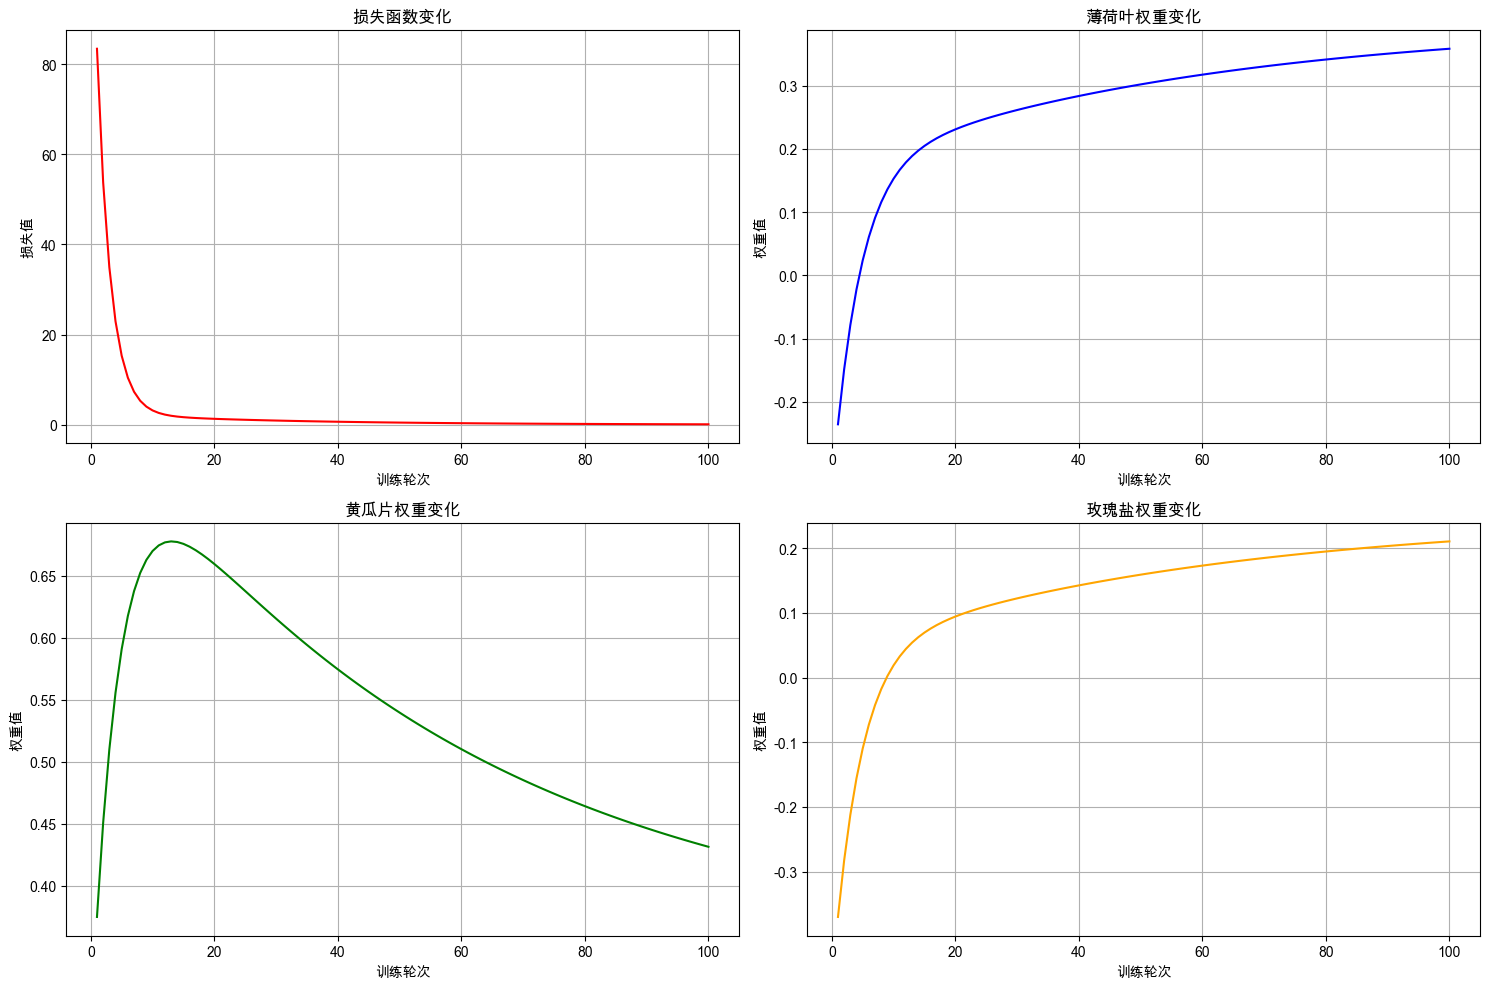

In [11]:
from util import set_seed

# 超参数配置
num_epochs = 100
samples_num = 800
lr = 0.001

set_seed(318)


# 将数组转换为 PyTorch 张量
train_features_tensor = torch.tensor(train_features[:samples_num], dtype=torch.float32)
train_targets_tensor = torch.tensor(train_targets[:samples_num], dtype=torch.float32)

# 定义损失函数和优化器
model = LemonadeRatingModel()  # 创建模型实例
loss_fn = nn.MSELoss()  # 使用均方误差损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=lr)  # 使用随机梯度下降优化器

# 调用训练方法
training_logs = train_model(model, train_features_tensor, train_targets_tensor, loss_fn, optimizer, num_epochs=num_epochs, log_interval=1)

# 可视化训练过程
plot_training_logs(training_logs)

从实验1中，我们可以看到，损失下降速度较慢但稳定，训练过程平滑，没有有剧烈波动。

### 实验2：样本数多，学习率高
- 训练轮数：100
- 样本数：800
- 学习率：0.009

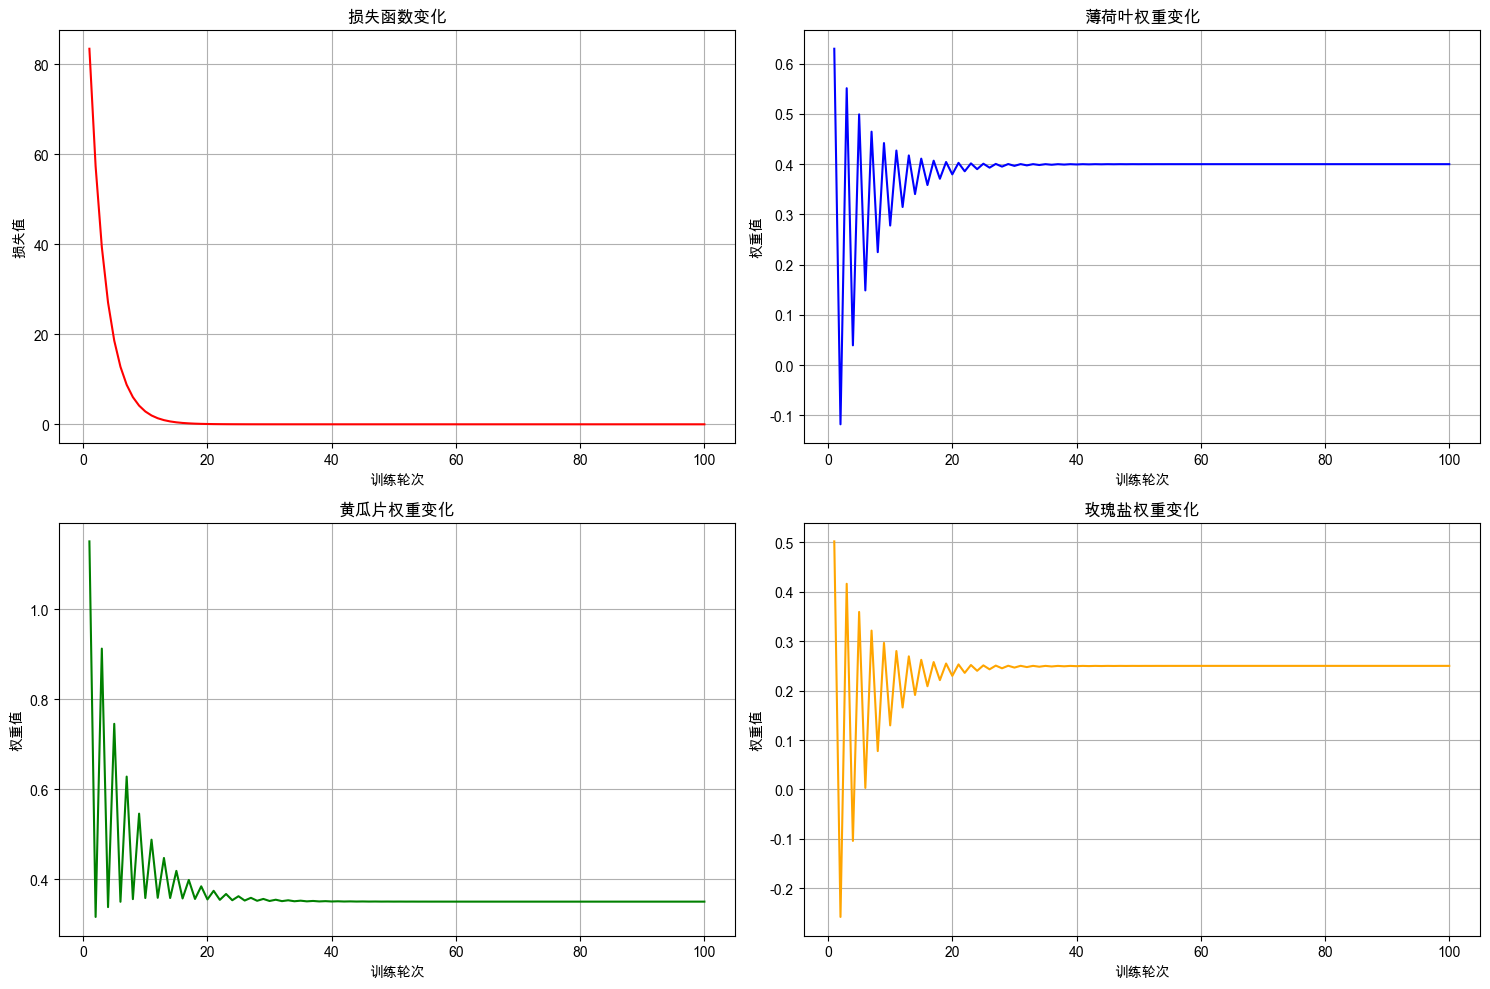

In [12]:
from util import set_seed

# 超参数配置
num_epochs = 100
samples_num = 800
lr = 0.009

set_seed(318)

# 将数组转换为 PyTorch 张量
train_features_tensor = torch.tensor(train_features[:samples_num], dtype=torch.float32)
train_targets_tensor = torch.tensor(train_targets[:samples_num], dtype=torch.float32)

# 定义损失函数和优化器
model = LemonadeRatingModel()  # 创建模型实例
loss_fn = nn.MSELoss()  # 使用均方误差损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=lr)  # 使用随机梯度下降优化器

# 调用训练方法
training_logs = train_model(model, train_features_tensor, train_targets_tensor, loss_fn, optimizer, num_epochs=num_epochs, log_interval=1)

# 可视化训练过程
plot_training_logs(training_logs)

从实验2中，我们可以看到，损失下降速度较快，在第20轮权重的值就接近最优值了，但训练的过程存在剧烈波动，训练过程不平滑，有较大的风险训练失败。

### 实验3：样本数少，学习率高
- 训练轮数：100
- 样本数：5
- 学习率：0.009

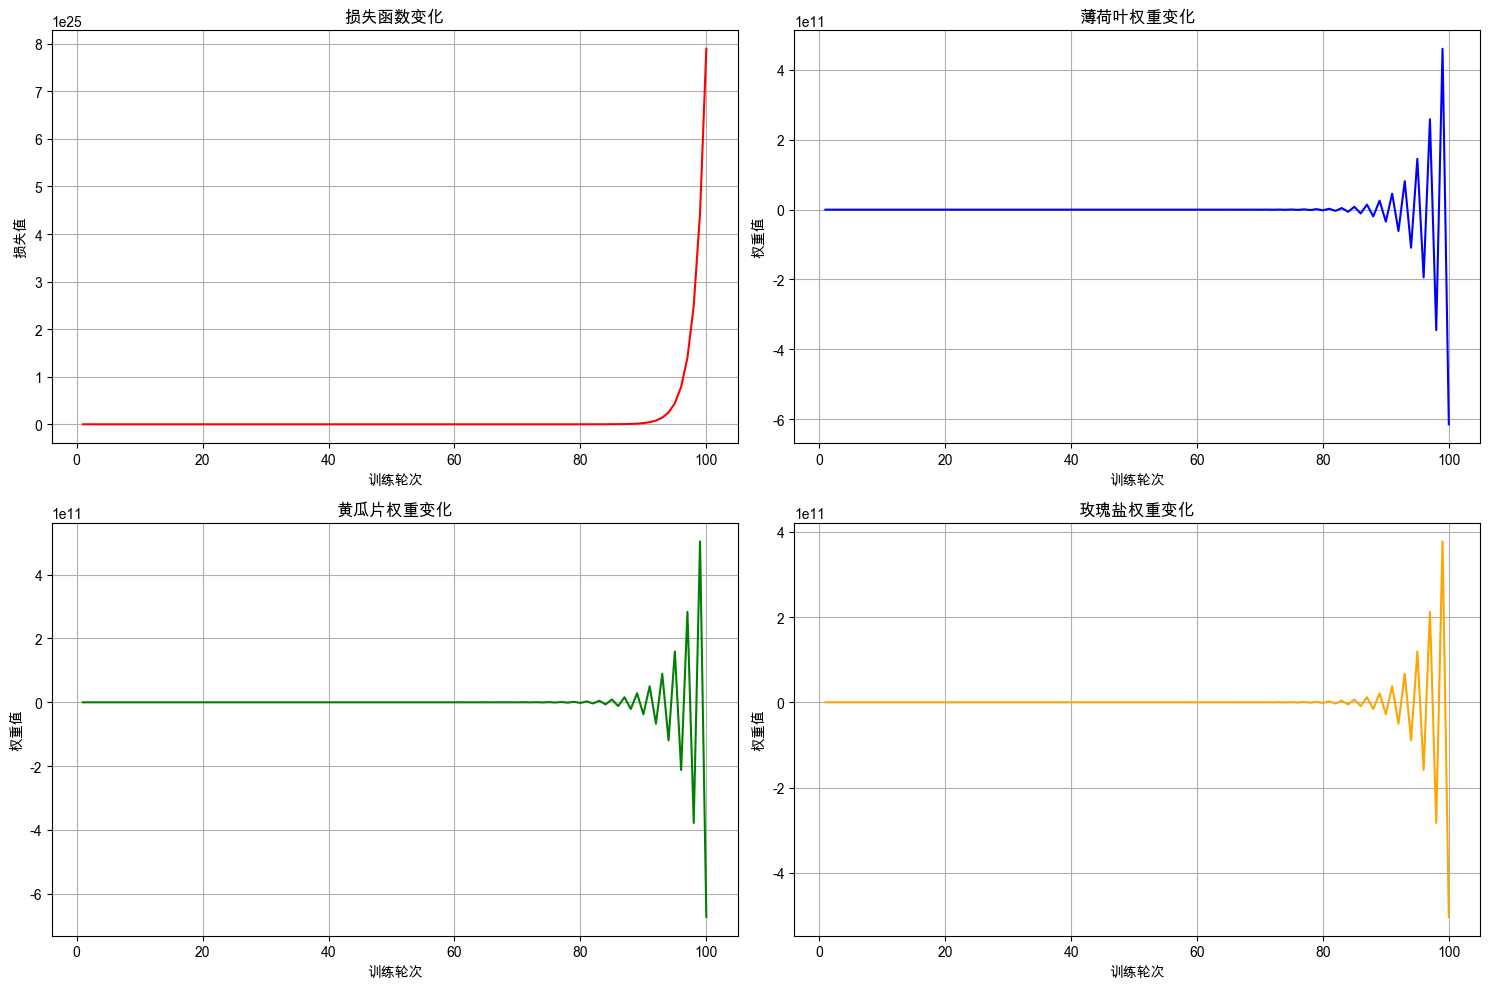

In [13]:
from util import set_seed

# 超参数配置
num_epochs = 100
samples_num = 5
lr = 0.009

set_seed(1024)

# 将数组转换为 PyTorch 张量
train_features_tensor = torch.tensor(train_features[:samples_num], dtype=torch.float32)
train_targets_tensor = torch.tensor(train_targets[:samples_num], dtype=torch.float32)

# 定义损失函数和优化器
model = LemonadeRatingModel()  # 创建模型实例
loss_fn = nn.MSELoss()  # 使用均方误差损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=lr)  # 使用随机梯度下降优化器

# 调用训练方法
training_logs = train_model(model, train_features_tensor, train_targets_tensor, loss_fn, optimizer, num_epochs=num_epochs, log_interval=1)

# 可视化训练过程
plot_training_logs(training_logs)

从结果中我们可以看到实验 3 训练彻底失败。和实验2相比，它只训练了5个样本导致训练失败。这说明：“数据就是智能的燃料”，就像一个火箭就算有再强的引擎，如果没有足够的燃料也无法到达期望的目的地。

这是本实验的关键教训：当数据量不足时，模型无法学习到真正的规律；越是复杂的模型训练所需的数据量越大。

### 实验的启示

通过这三组对比实验，我们系统分析了不同样本量与学习率的组合对模型训练的影响，具体实验设置及结果如下：
- 实验1：采用多样本量、低学习率设置 → 训练过程稳定，但收敛速度缓慢；
- 实验2：采用多样本量、高学习率设置 → 训练收敛速度加快，但过程波动剧烈；
- 实验3：采用少样本量、高学习率设置 → 训练直接失败。

上述三组实验结果为我们提供了一些关键启示：
- **首先，学习率对训练效果存在双重影响，需精准平衡。** 
    - 过小的学习率会显著延长训练周期，会降低训练效率，浪费大量的时间和算力成本；
    - 提升学习率虽能有效加速训练收敛，但会破坏训练稳定性，甚至可能导致训练失效。

因此，好的学习率调度策略对模型的训练至关重要。在后续项目中，我们会采用优化器动态管理模型参数的更新，让模型在训练过程又快又好。

- **其次，数据对模型训练效果具有根本性决定作用。**
数据量不足或质量欠佳，会直接导致训练失败。

实践表明，不少AI项目失败的核心原因，都在于对高质量数据采集的重视不足，反而过度将资源倾斜于模型开发与改进。事实上，数据采集的优先级应高于模型本身，其质量与数量直接决定项目成败，是AI项目实施过程中的至关重要的环节。

## 本章小结

本章作为神经网络与PyTorch框架的实战入门，核心目标是引导学习者从上一章手动实现单参数模型的阶段，平滑过渡到利用现代深度学习框架构建并自动化训练一个多参数神经网络模型。本章围绕“预测特调柠檬水顾客评分”这一生动背景，以多参数回归问题为切入点，系统展示了使用PyTorch进行机器学习项目的完整流程：从数据观察与加载，到模型定义，再到训练流程的构建。

本章的关键在于体验PyTorch框架带来的效率提升，它将学习者从繁琐的梯度手动推导与计算中解放出来。我们基于`模型层`、`损失函数`和`优化器`等核心组件成功训练了第一个可工作的PyTorch神经网络，这为理解深度学习框架的工作机制奠定了坚实基础。但是，在训练过程中，我们的数据还是比较低效的手动管理，在下一个章节中我们将会使用更深的网络、更高效的数据加载器（DataLoader）学习如何处理更复杂的分类问题。

:::{admonition} 本章所学内容 
:class: note
- 使用神经网络可以构建模型，通过训练可以获得类人的“智能”。
- 神经网络模型使用反向传播可以高效地自动计算梯度。
- PyTorch是一个开源的深度学习框架，可以快速构建神经网络模型并进行训练。
- 张量（Tensor），是 PyTorch 用于进行所有计算的基础数据结构。
- 机器学习中使用的数据集分为训练数据和测试数据。
- 神经网络用训练数据进行学习，并用测试数据评价学习到的模型的泛化能力。
- 神经网络的学习以损失函数为指标，用优化器更新权重参数，以使损失函数的值减小。
- 经典训练循环的核心步骤依次为：
    - 前向传播 `forward` 计算预测值
    - 利用损失函数 `loss_fn` 计算误差；
    - 使用优化器的 `zero_grad` 方法清零历史梯度；
    - 调用 `loss.backward()` 反向传播自动计算梯度；
    - 最后通过优化器的 `step` 方法更新模型参数。
:::